In [1]:
import random
from typing import List, Tuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import clear_output
from torch.distributions import Normal

In [2]:
def initialize_uniformly(layer: nn.Linear, init_w: float = 3e-3):
    layer.weight.data.uniform_(-init_w, init_w)
    layer.bias.data.uniform_(-init_w, init_w)


class Actor(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super(Actor, self).__init__()

        self.hidden1 = nn.Linear(in_dim, 128)
        self.mu_layer = nn.Linear(128, out_dim)
        self.log_std_layer = nn.Linear(128, out_dim)

        initialize_uniformly(self.mu_layer)
        initialize_uniformly(self.log_std_layer)

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.hidden1(state))

        mu = torch.tanh(self.mu_layer(x)) * 2
        log_std = F.softplus(self.log_std_layer(x))
        std = torch.exp(log_std)

        dist = Normal(mu, std)
        action = dist.sample()

        return action, dist


class Critic(nn.Module):
    def __init__(self, in_dim: int):
        super(Critic, self).__init__()

        self.hidden1 = nn.Linear(in_dim, 128)
        self.out = nn.Linear(128, 1)

        initialize_uniformly(self.out)

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.hidden1(state))
        value = self.out(x)

        return value

In [3]:
env = gym.make("Pendulum-v1", render_mode="rgb_array")

In [4]:
def seed_torch(seed):
    torch.manual_seed(seed)
    if torch.backends.cudnn.enabled:
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


seed = 777
random.seed(seed)
np.random.seed(seed)
seed_torch(seed)

In [5]:
def select_action(state: np.ndarray) -> np.ndarray:
    state = torch.FloatTensor(state).to(device)
    action, dist = actor(state)
    selected_action = action

    log_prob = dist.log_prob(selected_action).sum(dim=-1)

    return selected_action.clamp(-2.0, 2.0).cpu().detach().numpy(), state, log_prob

In [6]:
def step(action: np.ndarray) -> Tuple[np.ndarray, np.float64, bool]:
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    return next_state, reward, done

In [7]:
def update_model(state1, log_prob1, next_state1, reward1, done1) -> Tuple[torch.Tensor, torch.Tensor]:
    state, log_prob, next_state, reward, done = state1, log_prob1, next_state1, reward1, done1

    # Q_t   = r + gamma * V(s_{t+1})  if state != Terminal
    #       = r                       otherwise
    mask = 1 - done
    next_state = torch.FloatTensor(next_state).to(device)
    pred_value = critic(state)
    targ_value = reward + gamma * critic(next_state) * mask
    value_loss = F.smooth_l1_loss(pred_value, targ_value.detach())

    # update value
    critic_optimizer.zero_grad()
    value_loss.backward()
    critic_optimizer.step()

    # advantage = Q_t - V(s_t)
    advantage = (targ_value - pred_value).detach()  # not backpropagated
    policy_loss = -advantage * log_prob
    policy_loss += entropy_weight * -log_prob  # entropy maximization

    # update policy
    actor_optimizer.zero_grad()
    policy_loss.backward()
    actor_optimizer.step()

    return policy_loss.item(), value_loss.item()

In [8]:
def _plot(
    frame_idx: int,
    scores: List[float],
    actor_losses: List[float],
    critic_losses: List[float],
):
    """Plot the training progresses."""

    def subplot(loc: int, title: str, values: List[float]):
        plt.subplot(loc)
        plt.title(title)
        plt.plot(values)

    subplot_params = [
        (131, f"frame {frame_idx}. score: {np.mean(scores[-10:])}", scores),
        (132, "actor_loss", actor_losses),
        (133, "critic_loss", critic_losses),
    ]

    clear_output(True)
    plt.figure(figsize=(30, 5))
    for loc, title, values in subplot_params:
        subplot(loc, title, values)
    plt.show()

## Initialize

In [9]:
num_frames = 100000
gamma = 0.9
entropy_weight = 1e-2

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [11]:
# networks
obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
actor = Actor(obs_dim, action_dim).to(device)
critic = Critic(obs_dim).to(device)

In [12]:
# optimizer
actor_optimizer = optim.Adam(actor.parameters(), lr=1e-4)
critic_optimizer = optim.Adam(critic.parameters(), lr=1e-3)

In [13]:
# total steps count
total_step = 0

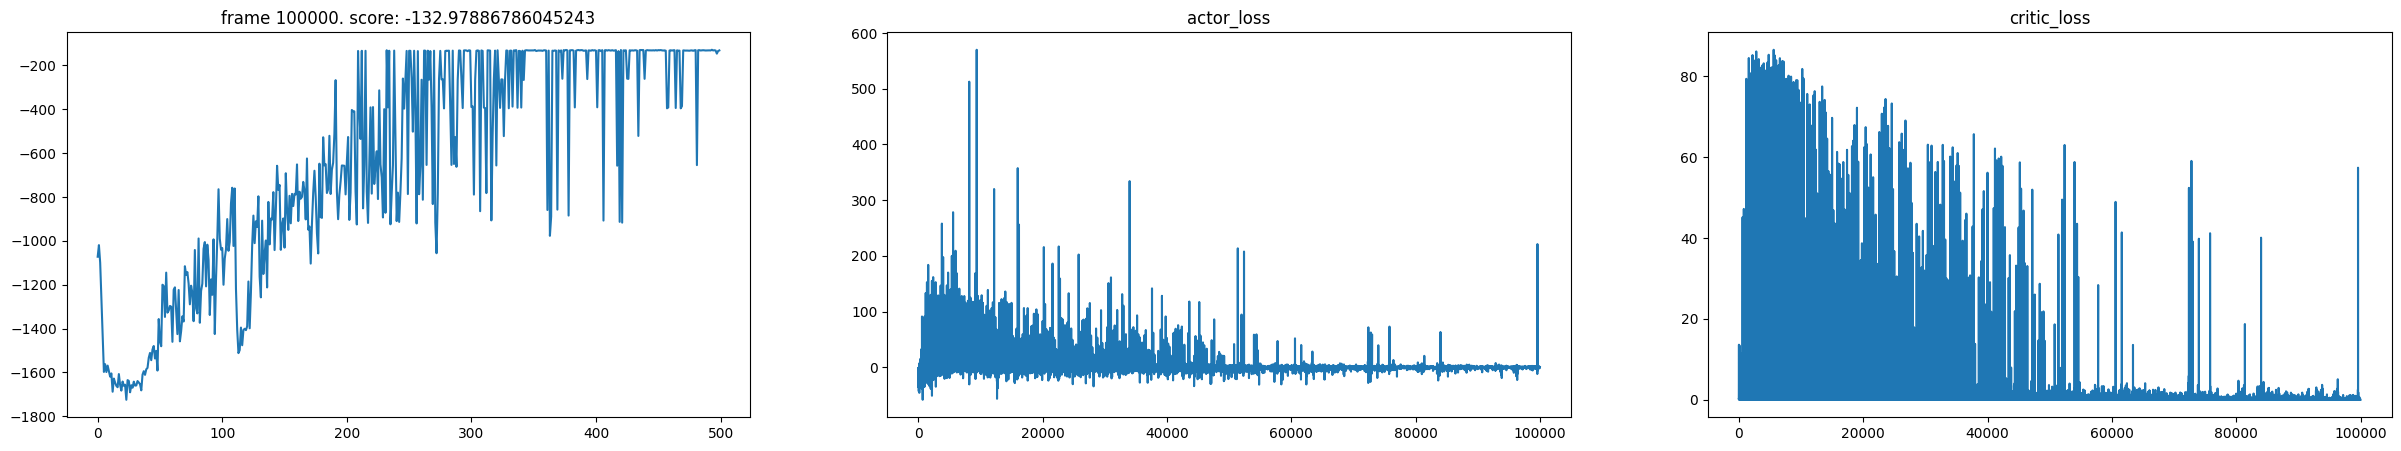

In [14]:
# train 

actor_losses, critic_losses, scores = [], [], []
state, _ = env.reset(seed=seed)
score = 0

for total_step in range(1, num_frames + 1):

    action, state, log_prob = select_action(state)
    next_state, reward, done = step(action)


    
    actor_loss, critic_loss = update_model(state, log_prob, next_state, reward, done)
    actor_losses.append(actor_loss)
    critic_losses.append(critic_loss)

    state = next_state
    score += reward

    # if episode ends
    if done:
        state, _ = env.reset(seed=seed)
        scores.append(score)
        score = 0

    # plot
    if total_step % 200 == 0:
        _plot(total_step, scores, actor_losses, critic_losses)
env.close()